In [9]:
import os
import sys

sys.path.append("../src")

os.environ["OPENCV_LOG_LEVEL"] = "SILENT"
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras import layers, models

from preprocess import load_signature_data

Image shape: (3120, 128, 128)
Labels shape: (3120,)


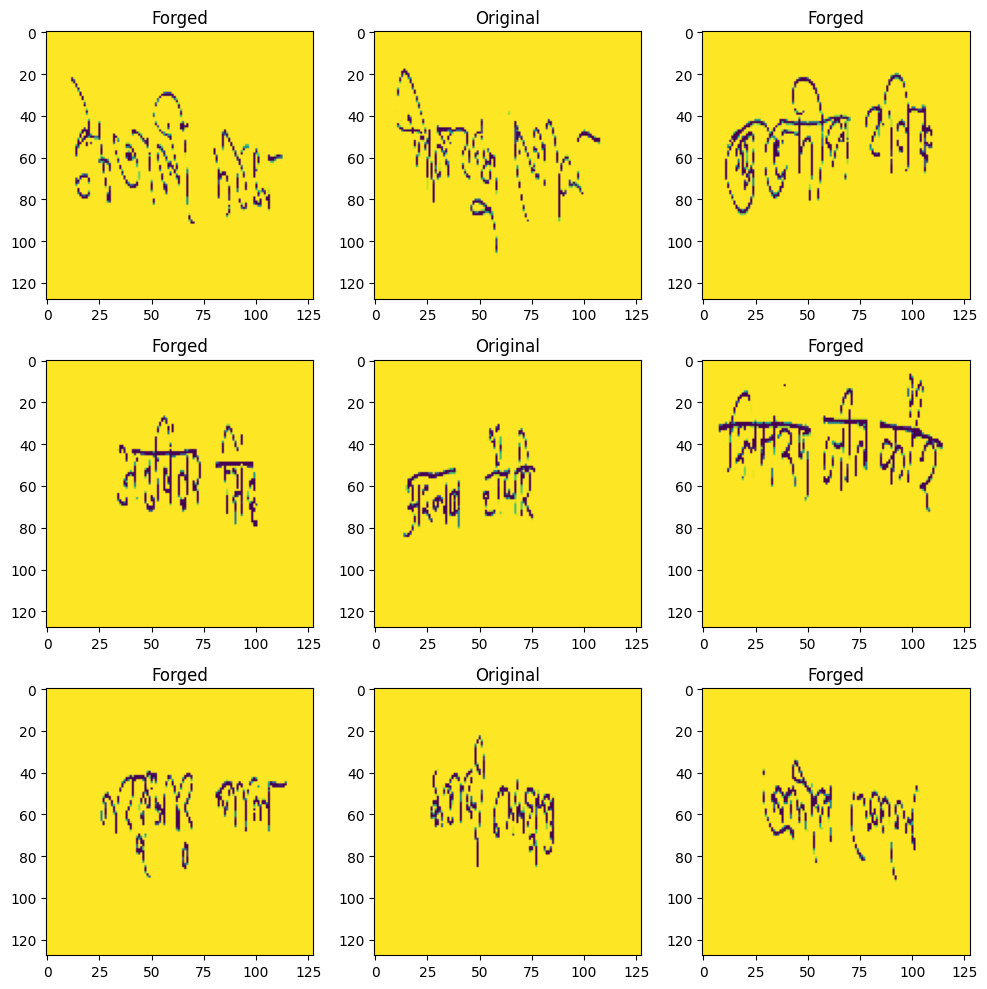

In [10]:
# IMPORTANT: move to project root so dataset path works
import os
os.chdir("..")

# load data
sig_images, sig_labels = load_signature_data()

print("Image shape:", sig_images.shape)
print("Labels shape:", sig_labels.shape)


# ===== SHOW MIXED GRID =====
indices = list(range(len(sig_labels)))
random.shuffle(indices)

plt.figure(figsize=(10,10))

for i in range(9):
    idx = indices[i]
    
    plt.subplot(3,3,i+1)
    plt.imshow(sig_images[idx])
    plt.title("Original" if sig_labels[idx]==0 else "Forged")

plt.tight_layout()
plt.show()

In [19]:
#  FIXED PREPROCESS + SPLIT 

# convert to 3 channels (IMPORTANT FIX)
sig_images = np.stack([sig_images]*3, axis=-1)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    sig_images, sig_labels,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2496, 128, 128, 3)
Test: (624, 128, 128, 3)


In [9]:
from tensorflow.keras import layers, models

def build_model(base):
    base.trainable = False

    x = base.output
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Epoch 1/5
156/156 [==============================] - 90s 574ms/step - loss: 0.5860 - accuracy: 0.6931 - val_loss: 0.4255 - val_accuracy: 0.8269
Epoch 2/5
156/156 [==============================] - 94s 602ms/step - loss: 0.4207 - accuracy: 0.8001 - val_loss: 0.3393 - val_accuracy: 0.8686
Epoch 3/5
156/156 [==============================] - 95s 613ms/step - loss: 0.3349 - accuracy: 0.8542 - val_loss: 0.3924 - val_accuracy: 0.8077
Epoch 4/5
156/156 [==============================] - 97s 625ms/step - loss: 0.2729 - accuracy: 0.8926 - val_loss: 0.4562 - val_accuracy: 0.7596
Epoch 5/5
20/20 [==============================] - 20s 981ms/step - loss: 0.3327 - accuracy: 0.8301
VGG16 Accuracy: 0.8301281929016113


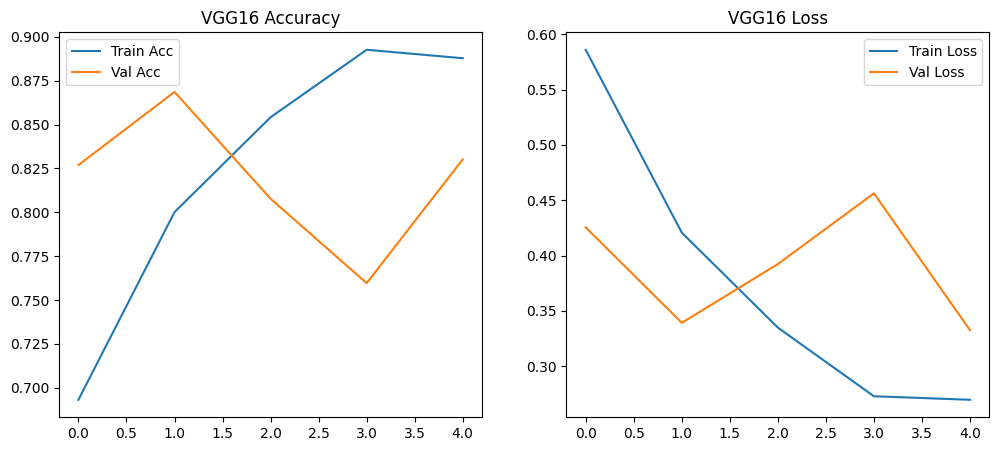

In [15]:
# MODEL VGG16 
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
vgg_model = build_model(vgg_base)

history_vgg = vgg_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(X_test, y_test)
)

_, vgg_acc = vgg_model.evaluate(X_test, y_test)
print("VGG16 Accuracy:", vgg_acc)


# ===== GRAPH =====
import matplotlib.pyplot as plt

def plot_graph(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_graph(history_vgg, "VGG16")

Epoch 1/5
156/156 [==============================] - 34s 210ms/step - loss: 0.7131 - accuracy: 0.5284 - val_loss: 0.6603 - val_accuracy: 0.5176
Epoch 2/5
156/156 [==============================] - 33s 209ms/step - loss: 0.6419 - accuracy: 0.6038 - val_loss: 0.6337 - val_accuracy: 0.6346
Epoch 3/5
156/156 [==============================] - 33s 210ms/step - loss: 0.6252 - accuracy: 0.6554 - val_loss: 0.6231 - val_accuracy: 0.6635
Epoch 4/5
156/156 [==============================] - 34s 220ms/step - loss: 0.6155 - accuracy: 0.6695 - val_loss: 0.6164 - val_accuracy: 0.6522
Epoch 5/5
20/20 [==============================] - 6s 297ms/step - loss: 0.6079 - accuracy: 0.6635
ResNet Accuracy: 0.6634615659713745


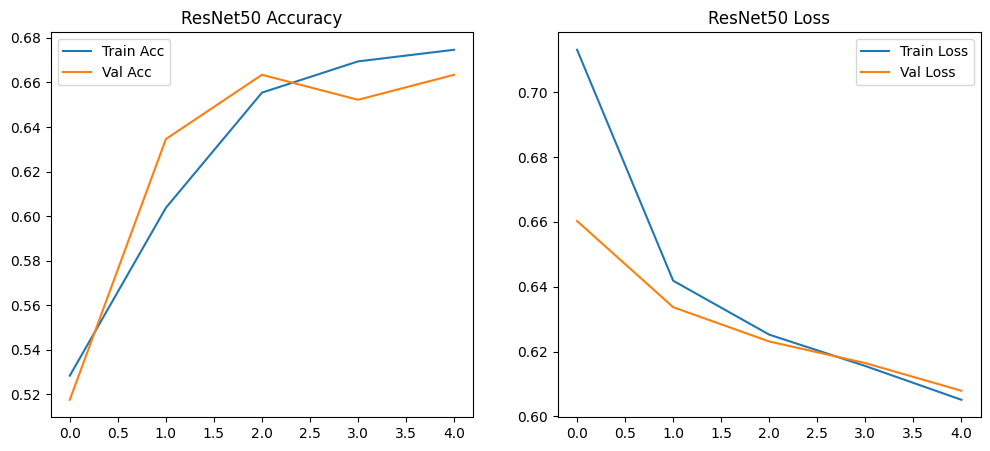

In [16]:
# MODEL RESNET 
from tensorflow.keras.applications import ResNet50

res_base = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
res_model = build_model(res_base)

history_res = res_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(X_test, y_test)
)

_, res_acc = res_model.evaluate(X_test, y_test)
print("ResNet Accuracy:", res_acc)

plot_graph(history_res, "ResNet50")

Epoch 1/5
156/156 [==============================] - 12s 76ms/step - loss: 0.6687 - accuracy: 0.5713 - val_loss: 0.5946 - val_accuracy: 0.6426
Epoch 2/5
156/156 [==============================] - 12s 74ms/step - loss: 0.5682 - accuracy: 0.6767 - val_loss: 0.5114 - val_accuracy: 0.7420
Epoch 3/5
156/156 [==============================] - 11s 73ms/step - loss: 0.4549 - accuracy: 0.7800 - val_loss: 0.4254 - val_accuracy: 0.7949
Epoch 4/5
156/156 [==============================] - 12s 77ms/step - loss: 0.3609 - accuracy: 0.8281 - val_loss: 0.3901 - val_accuracy: 0.8301
Epoch 5/5
156/156 [==============================] - 12s 78ms/step - loss: 0.2623 - accuracy: 0.8830 - val_loss: 0.3409 - val_accuracy: 0.8526


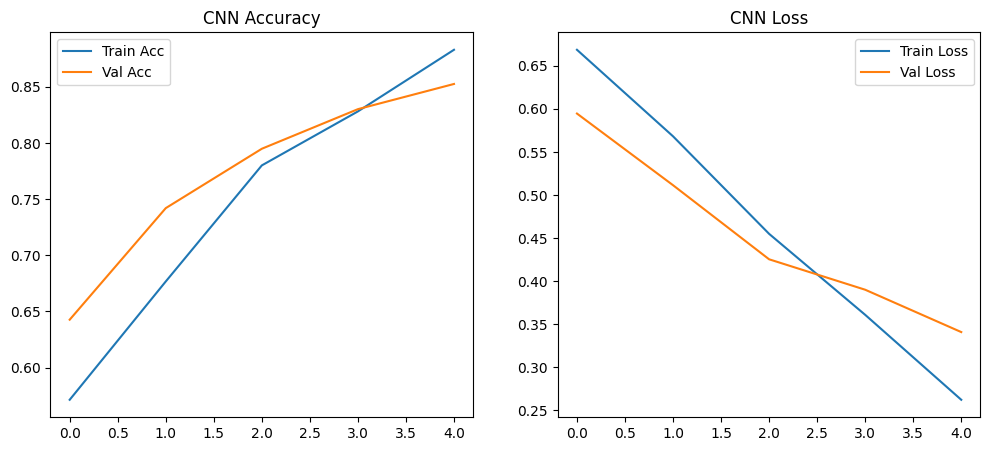

In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ===== CNN MODEL (IMPROVED) =====
cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),   # 🔥 extra layer
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),   # 🔥 important

    layers.Dense(1,activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== EARLY STOPPING =====
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# ===== TRAIN =====
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=5,   
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ===== GRAPH =====
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.title("CNN Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title("CNN Loss")
plt.legend()

plt.show()

20/20 [==============================] - 1s 38ms/step


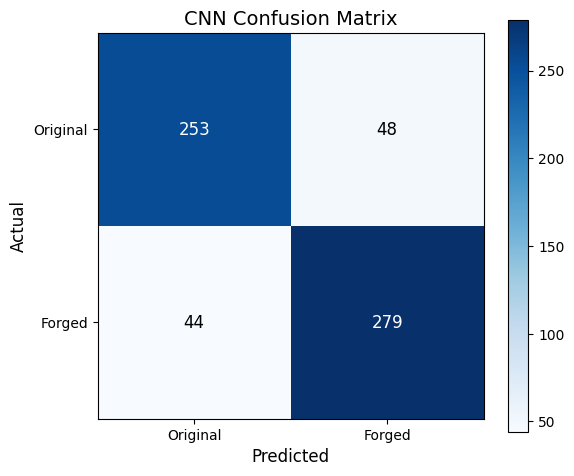

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# predictions
y_pred = cnn_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

labels = ["Original", "Forged"]

plt.figure(figsize=(6,5))

# sky-blue colormap
plt.imshow(cm, cmap="Blues")

plt.title("CNN Confusion Matrix", fontsize=14)
plt.colorbar()

ticks = np.arange(len(labels))
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

# numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontsize=12)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

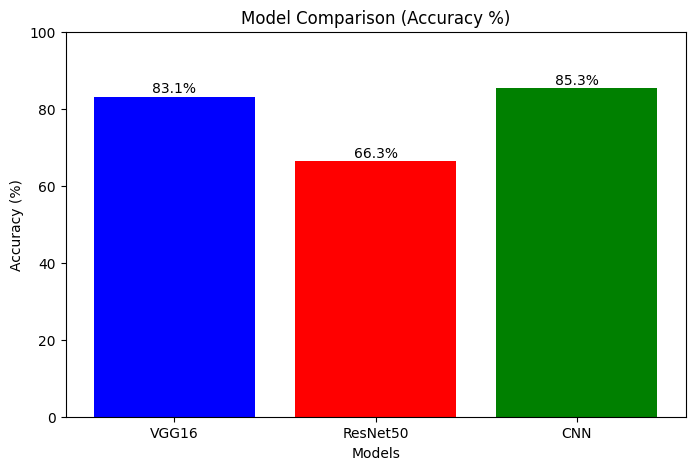

In [29]:
import matplotlib.pyplot as plt

results = {
    "VGG16": 0.831281929016113,
    "ResNet50": 0.6634615659713745,
    "CNN": 0.8526
}

models = list(results.keys())

# convert to percentage
accuracies = [v * 100 for v in results.values()]

colors = ['blue', 'red', 'green']

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=colors)

# values on top (as %)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Model Comparison (Accuracy %)")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [34]:
cnn_model.save("models/sign_model.h5")